<a href="https://colab.research.google.com/github/alperdinceler/Machine-learning/blob/main/Kar%C5%9F%C4%B1la%C5%9Ft%C4%B1rma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Decision Tree vs XGBoost — Kapsamlı Karşılaştırma

---

## 📚 1. Temel Algoritma ve Topluluk (Ensemble) Öğrenme Arasındaki Fark Nedir?

Bu notebook'ta, makine öğrenmesindeki en temel kural tabanlı algoritmalardan biri olan **Karar Ağacı (Decision Tree)** ile, yüzlerce karar ağacının hatalarından ders çıkararak birleştiği son teknoloji bir model olan **XGBoost'u** karşılaştıracağız.

- **Decision Tree (Tekil Model):** Veriyi tek bir ağaç yapısıyla bölerek karara ulaşır. Yüksek varyansa (overfitting'e) meyillidir.
- **XGBoost (Topluluk Model):** Zayıf karar ağaçlarını (stumps/shallow trees) ardışık olarak birleştirir ve her yeni ağaç bir öncekinin hatasını düzeltir.

---

## 🟡 2. Karar Ağacı (Decision Tree)

### Ne Yapar?
- İnsan karar verme sürecini taklit eden en anlaşılır algoritmalardan biridir.
- Veri setini, hedef değişkendeki saflığı (purity) en üst düzeye çıkaracak şekilde "Eğer-Değilse" (If-Else) kurallarıyla dallara ayırır.
- Kök düğümden (root node) başlayarak yaprak düğümlere (leaf nodes) kadar iner.

### Matematiksel Temel
Karar ağaçları bölünme noktalarını seçmek için "Bilgi Kazancı" (Information Gain) veya "Gini Safsızlığı" (Gini Impurity) kullanır.

**Gini Safsızlığı (CART algoritması için):**
Bir düğümdeki sınıfların karışıklık derecesini ölçer. 0 mükemmel saflık demektir.
$$Gini = 1 - \sum_{i=1}^{C} (p_i)^2$$
Burada $p_i$, o düğümdeki $i$ sınıfına ait örneklerin olasılığıdır.

**Entropi (Bilgi Kazancı için):**
$$Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

### Özellikleri
| Özellik | Değer |
|---------|-------|
| Temel Mantık | Veriyi kurallarla bölme (Recursive Partitioning) |
| Yorumlanabilirlik | **Çok Yüksek** (Görselleştirilebilir) |
| Overfitting (Aşırı Öğrenme) | **Çok Yüksek Risk** (Budama yapılmazsa) |
| Eğitim Hızı | Çok Hızlı |
| Veri Hazırlığı | Ölçeklendirme gerektirmez |

In [ ]:
# ─── Temel veri işleme kütüphaneleri ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn araçları ──────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier    # Karar Ağacı sınıflandırıcısı
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

import xgboost as xgb      # XGBoost kütüphanesi
import time

# ─── Görsel ayarlar ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Tüm kütüphaneler başarıyla yüklendi!')
print(f'   XGBoost versiyonu: {xgb.__version__}')

# ─── Veri setini yükle ve böl ───────────────────────────────────────────────
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='hedef')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\\n📋 Eğitim seti: {X_train.shape[0]} örnek')
print(' DECISION TREE MODELİ EĞİTİLİYOR...')
print('='*45)

# ─── Karar Ağacı modelini tanımla ───────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    criterion='gini',       # Bölünme kalitesini ölçen fonksiyon (gini veya entropy)
    max_depth=None,         # None bırakılırsa ağaç saf yapraklara kadar büyür (Overfit riski!)
    min_samples_split=2,    # Bir düğümü bölmek için gereken minimum örnek sayısı
    random_state=42
)

# ─── Eğitim ─────────────────────────────────────────────────────────────────
start = time.time()
dt_model.fit(X_train, y_train)
dt_time = time.time() - start

# ─── Tahmin ve Metrikler ────────────────────────────────────────────────────
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

dt_acc    = accuracy_score(y_test, dt_pred)
dt_auc    = roc_auc_score(y_test, dt_prob)
dt_f1     = f1_score(y_test, dt_pred)
dt_prec   = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)

print(f'✅ Eğitim Süresi   : {dt_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {dt_acc:.4f}  ({dt_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {dt_auc:.4f}')
print(f'📊 Ağaç Derinliği  : {dt_model.get_depth()} (Algoritmanın ulaştığı derinlik)')
print('\\n📋 Detaylı Rapor:')
print(classification_report(y_test, dt_pred, target_names=['Malignant', 'Benign']))

✅ Tüm kütüphaneler başarıyla yüklendi!
   XGBoost versiyonu: 3.2.0
\n📋 Eğitim seti: 455 örnek
 DECISION TREE MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 0.0418 sn
📊 Doğruluk (Acc)  : 0.9123  (91.23%)
📊 AUC-ROC         : 0.9157
📊 Ağaç Derinliği  : 7 (Algoritmanın ulaştığı derinlik)
\n📋 Detaylı Rapor:
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



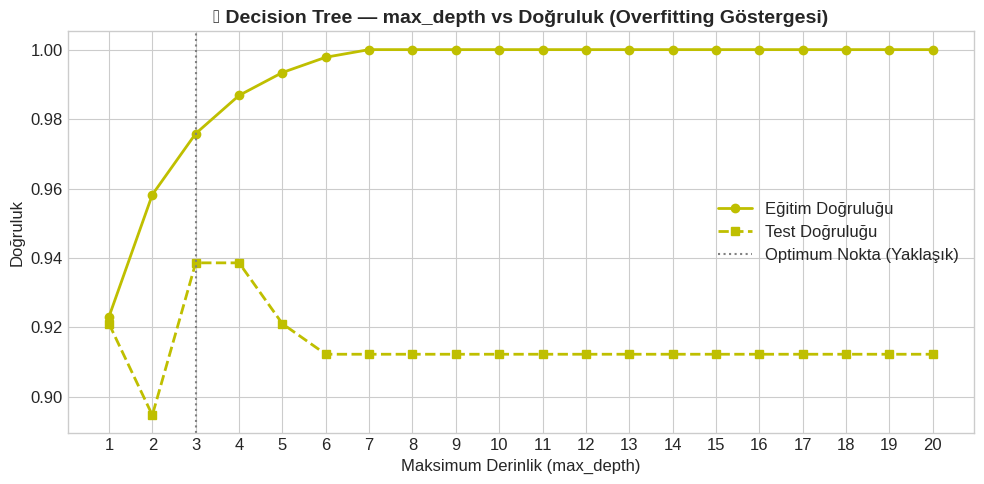

In [ ]:
# ─── Ağaç Derinliğine (max_depth) Göre Overfitting Analizi ──────────────────
# Karar ağaçlarında derinlik arttıkça model ezberlemeye (overfit) başlar.
depth_range = range(1, 21)
dt_train_scores = []
dt_test_scores  = []

for d in depth_range:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    dt_train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    dt_test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depth_range, dt_train_scores, 'y-o', label='Eğitim Doğruluğu', linewidth=2)
plt.plot(depth_range, dt_test_scores, 'y--s', label='Test Doğruluğu', linewidth=2)

plt.xlabel('Maksimum Derinlik (max_depth)', fontsize=12)
plt.ylabel('Doğruluk', fontsize=12)
plt.title('🟡 Decision Tree — max_depth vs Doğruluk (Overfitting Göstergesi)', fontsize=14, fontweight='bold')
plt.xticks(depth_range)
plt.axvline(x=3, color='gray', linestyle=':', label='Optimum Nokta (Yaklaşık)')
plt.legend()
plt.tight_layout()
plt.show()

# Grafik Yorumu: Eğitim doğruluğu %100'e (1.0) ulaşırken, test doğruluğu belirli bir
# derinlikten sonra düşüşe geçer veya sabit kalır. İşte bu "Aşırı Öğrenme"dir!

In [ ]:
print('🟢 XGBOOST MODELİ EĞİTİLİYOR...')
print('='*45)

# ─── XGBoost modelini tanımla ───────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,            # Her bir zayıf ağacın derinliği sınırlı (Overfit'i engeller)
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

# ─── Eğitim ─────────────────────────────────────────────────────────────────
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

# ─── Tahmin ve Metrikler ────────────────────────────────────────────────────
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_acc    = accuracy_score(y_test, xgb_pred)
xgb_auc    = roc_auc_score(y_test, xgb_prob)
xgb_f1     = f1_score(y_test, xgb_pred)
xgb_prec   = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)

print(f'✅ Eğitim Süresi   : {xgb_time:.4f} sn')
print(f'📊 Doğruluk (Acc)  : {xgb_acc:.4f}  ({xgb_acc*100:.2f}%)')
print(f'📊 AUC-ROC         : {xgb_auc:.4f}')
print('\\n📋 Detaylı Rapor:')
print(classification_report(y_test, xgb_pred, target_names=['Malignant', 'Benign']))

🟢 XGBOOST MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 0.8640 sn
📊 Doğruluk (Acc)  : 0.9474  (94.74%)
📊 AUC-ROC         : 0.9947
\n📋 Detaylı Rapor:
              precision    recall  f1-score   support

   Malignant       0.95      0.90      0.93        42
      Benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



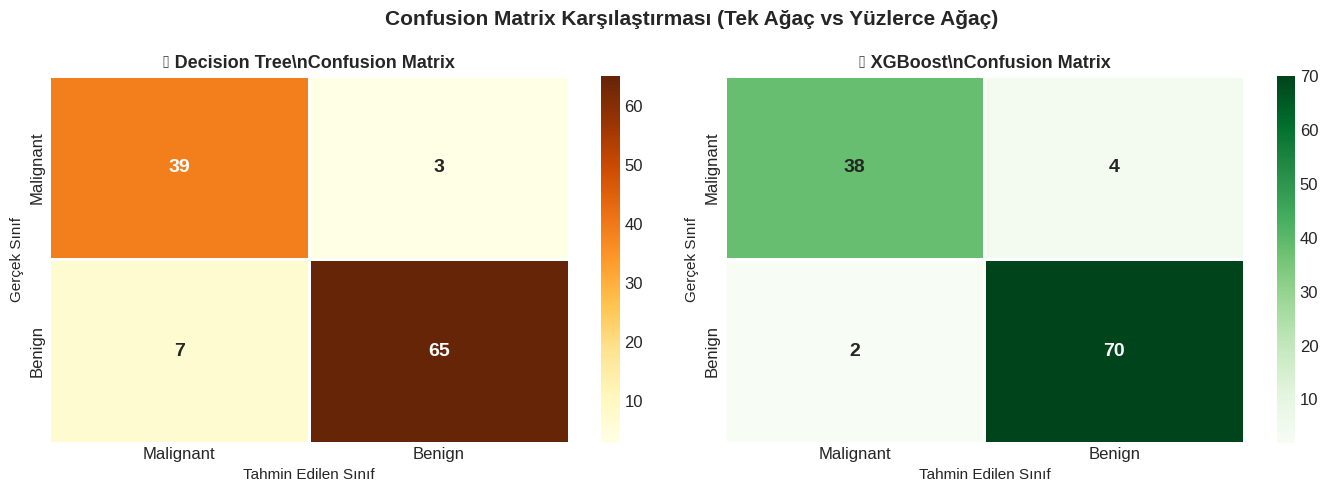

In [ ]:
# ─── Confusion Matrix Karşılaştırması ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title, color in zip(
    axes,
    [dt_pred, xgb_pred],
    ['🟡 Decision Tree', '🟢 XGBoost'],
    ['YlOrBr', 'Greens']  # Sarı/Turuncu (Tree) ve Yeşil (XGBoost) teması
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'],
                linewidths=2, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{title}\\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('Gerçek Sınıf', fontsize=11)
    ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11)

plt.suptitle('Confusion Matrix Karşılaştırması (Tek Ağaç vs Yüzlerce Ağaç)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

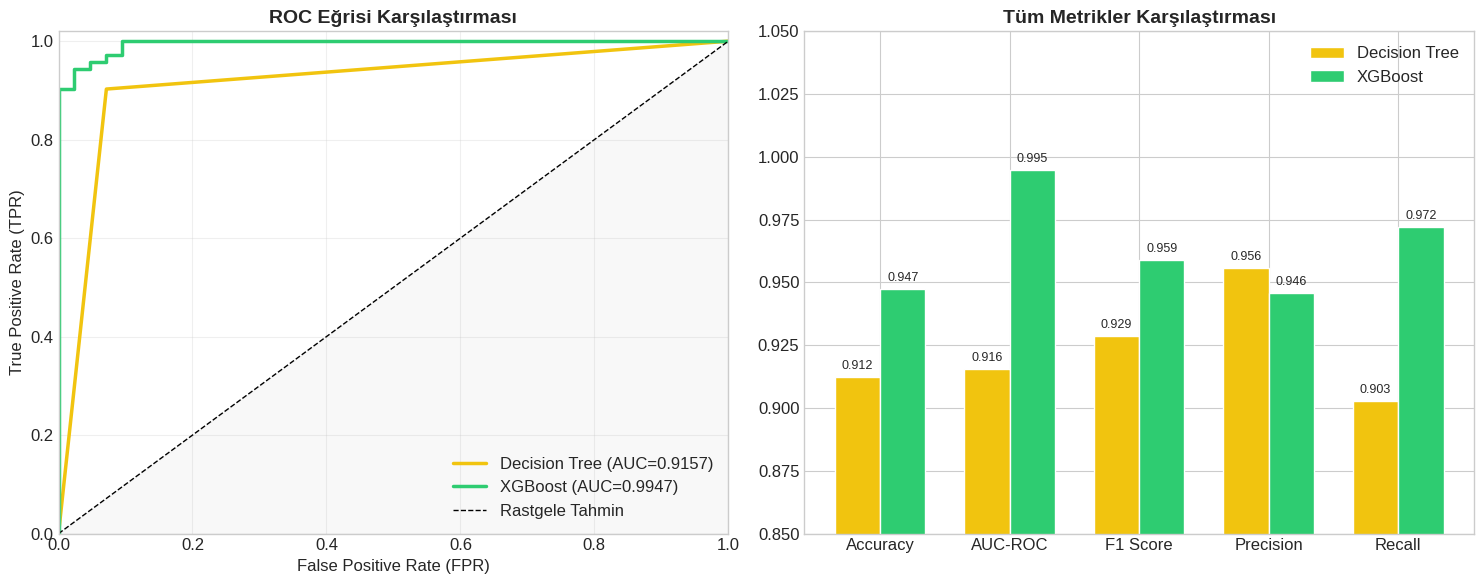

In [ ]:
# ─── ROC Eğrisi + Metrik Bar Grafiği ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Sol: ROC Eğrisi ──
for prob, label, color, acc, auc in [
    (dt_prob, 'Decision Tree', '#f1c40f', dt_acc, dt_auc),
    (xgb_prob, 'XGBoost',      '#2ecc71', xgb_acc, xgb_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2.5, label=f'{label} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele Tahmin')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate (FPR)'); axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

# Not: Decision Tree'nin ROC eğrisi genellikle köşeli olur çünkü yaprak düğümlerde saf sınıflara
# ulaştığı için olasılık değerleri genellikle 0 veya 1'dir. XGBoost ise çok daha yumuşak bir eğri çizer.

# ── Sağ: Metrik Bar Grafiği ──
metrics    = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
dt_scores  = [dt_acc, dt_auc, dt_f1, dt_prec, dt_recall]
xgb_scores = [xgb_acc, xgb_auc, xgb_f1, xgb_prec, xgb_recall]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1].bar(x - width/2, dt_scores, width, label='Decision Tree', color='#f1c40f', edgecolor='white')
bars2 = axes[1].bar(x + width/2, xgb_scores, width, label='XGBoost', color='#2ecc71', edgecolor='white')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
axes[1].set_title('Tüm Metrikler Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].legend(); axes[1].set_ylim(0.85, 1.05)

plt.tight_layout()
plt.show()

In [ ]:
# ─── Çapraz Doğrulama (Cross Validation) Skoru Hesapla ──────────────────────
dt_cv = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

# ─── Tabloyu Oluştur ────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'AUC-ROC', 'F1 Score', 'CV Ortalama', 'CV Std', 'Eğitim Süresi (sn)'],
    'Decision Tree 🟡': [
        f'{dt_acc:.4f}', f'{dt_auc:.4f}', f'{dt_f1:.4f}',
        f'{dt_cv.mean():.4f}', f'{dt_cv.std():.4f}', f'{dt_time:.4f}'
    ],
    'XGBoost 🟢': [
        f'{xgb_acc:.4f}', f'{xgb_auc:.4f}', f'{xgb_f1:.4f}',
        f'{xgb_cv.mean():.4f}', f'{xgb_cv.std():.4f}', f'{xgb_time:.4f}'
    ],
    'Kazanan': [
        '🟢 XGBoost' if xgb_acc >= dt_acc else '🟡 Decision Tree',
        '🟢 XGBoost' if xgb_auc >= dt_auc else '🟡 Decision Tree',
        '🟢 XGBoost' if xgb_f1  >= dt_f1  else '🟡 Decision Tree',
        '🟢 XGBoost' if xgb_cv.mean() >= dt_cv.mean() else '🟡 Decision Tree',
        '🟢 XGBoost' if xgb_cv.std()  <= dt_cv.std()  else '🟡 Decision Tree',
        '🟢 XGBoost' if xgb_time <= dt_time else '🟡 Decision Tree' # Sürede kısa olan kazanır
    ]
})

print('\\n' + '='*65)
print('         📊 DECISION TREE vs XGBOOST — SONUÇ TABLOSU')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

\n=================================================================
         📊 DECISION TREE vs XGBOOST — SONUÇ TABLOSU
            Metrik Decision Tree 🟡 XGBoost 🟢         Kazanan
          Accuracy          0.9123    0.9474       🟢 XGBoost
           AUC-ROC          0.9157    0.9947       🟢 XGBoost
          F1 Score          0.9286    0.9589       🟢 XGBoost
       CV Ortalama          0.9173    0.9684       🟢 XGBoost
            CV Std          0.0242    0.0181       🟢 XGBoost
Eğitim Süresi (sn)          0.0418    0.8640 🟡 Decision Tree
